In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"
df5 = pd.read_csv(url, encoding="latin-1")

df5 = df5[["v1", "v2"]]
df5.columns = ["label", "mesaj"]

df5.head()

,label,mesaj
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print(df5.shape)
print(df5["label"].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


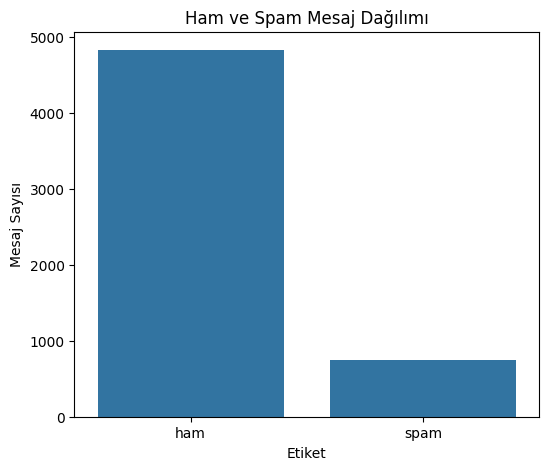

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.countplot(data=df5, x="label")
plt.title("Ham ve Spam Mesaj Dağılımı")
plt.xlabel("Etiket")
plt.ylabel("Mesaj Sayısı")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X6 = df5["mesaj"]
y6 = df5["label"]

X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y6, test_size=0.2, random_state=42)

vektorlestirici = TfidfVectorizer()
X6_train_vec = vektorlestirici.fit_transform(X6_train)
X6_test_vec = vektorlestirici.transform(X6_test)

print(X6_train_vec.shape)

(4457, 7735)


In [ ]:
from sklearn.linear_model import LogisticRegression

model_spam = LogisticRegression()
model_spam.fit(X6_train_vec, y6_train)

tahmin_spam = model_spam.predict(X6_test_vec)
print(tahmin_spam[:10])
print(y6_test[:10].values)

['ham' 'ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham']
['ham' 'ham' 'spam' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham']


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y6_test, tahmin_spam))
print("Precision:", precision_score(y6_test, tahmin_spam, pos_label="spam"))
print("Recall:", recall_score(y6_test, tahmin_spam, pos_label="spam"))
print("F1 Score:", f1_score(y6_test, tahmin_spam, pos_label="spam"))
print("Confusion Matrix:\n", confusion_matrix(y6_test, tahmin_spam))

Accuracy: 0.967713004484305
Precision: 0.9913793103448276
Recall: 0.7666666666666667
F1 Score: 0.8646616541353384
Confusion Matrix:
 [[964   1]
 [ 35 115]]


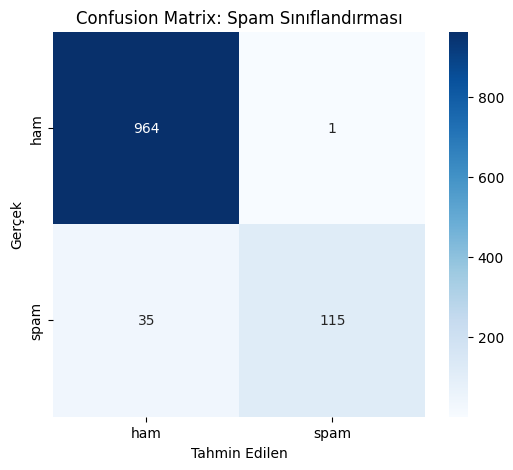

In [ ]:
import numpy as np

cm = confusion_matrix(y6_test, tahmin_spam)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix: Spam Sınıflandırması")
plt.show()

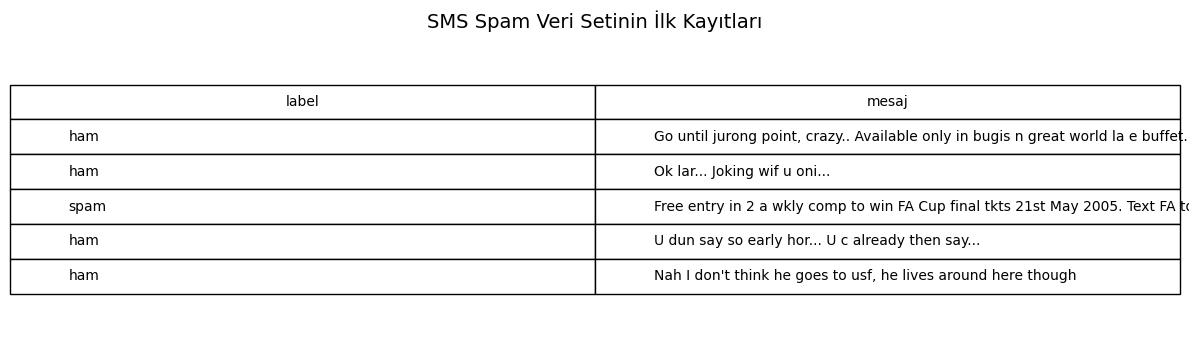

In [ ]:
import matplotlib.pyplot as plt

ilk_kayitlar = df5.head(5)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis("off")

tablo = ax.table(
    cellText=ilk_kayitlar.values,
    colLabels=ilk_kayitlar.columns,
    cellLoc="left",
    loc="center"
)

tablo.auto_set_font_size(False)
tablo.set_fontsize(10)
tablo.scale(1, 2)

plt.title("SMS Spam Veri Setinin İlk Kayıtları", fontsize=14, pad=15)
plt.tight_layout()
plt.show()